In [2]:
import pandas as pd

files = [
    "business_interruption_imputed.xlsx",
    "cargo_imputed.xlsx",
    "equipment_failure_imputed_data.xlsx",
    "fix_cleaned_workcomp.xlsx",
]

for f in files:
    sheets = pd.ExcelFile(f).sheet_names
    print(f"{f}: {sheets}")

business_interruption_imputed.xlsx: ['freq', 'sev']
cargo_imputed.xlsx: ['cargo_frequency', 'cargo_severity']
equipment_failure_imputed_data.xlsx: ['freq_final', 'sev_final']
fix_cleaned_workcomp.xlsx: ['freq', 'sev']



Business Interruption
  Count  : 9,997
  Mean   : 4,374,014.83
  Median : 2,138,430.00
  Std    : 7,494,337.26
  Min    : 28,265.00
  Max    : 142,583,386.00

Cargo
  Count  : 30,561
  Mean   : 7,781,811.16
  Median : 381,348.00
  Std    : 22,857,068.61
  Min    : 1,464.00
  Max    : 678,000,000.00

Equipment Failure
  Count  : 8,198
  Mean   : 88,014.71
  Median : 73,081.50
  Std    : 62,594.61
  Min    : 11,120.00
  Max    : 790,000.00

Work Compensation
  Count  : 1,912
  Mean   : 7,730.84
  Median : 2,007.11
  Std    : 18,351.16
  Min    : 120.76
  Max    : 162,432.21


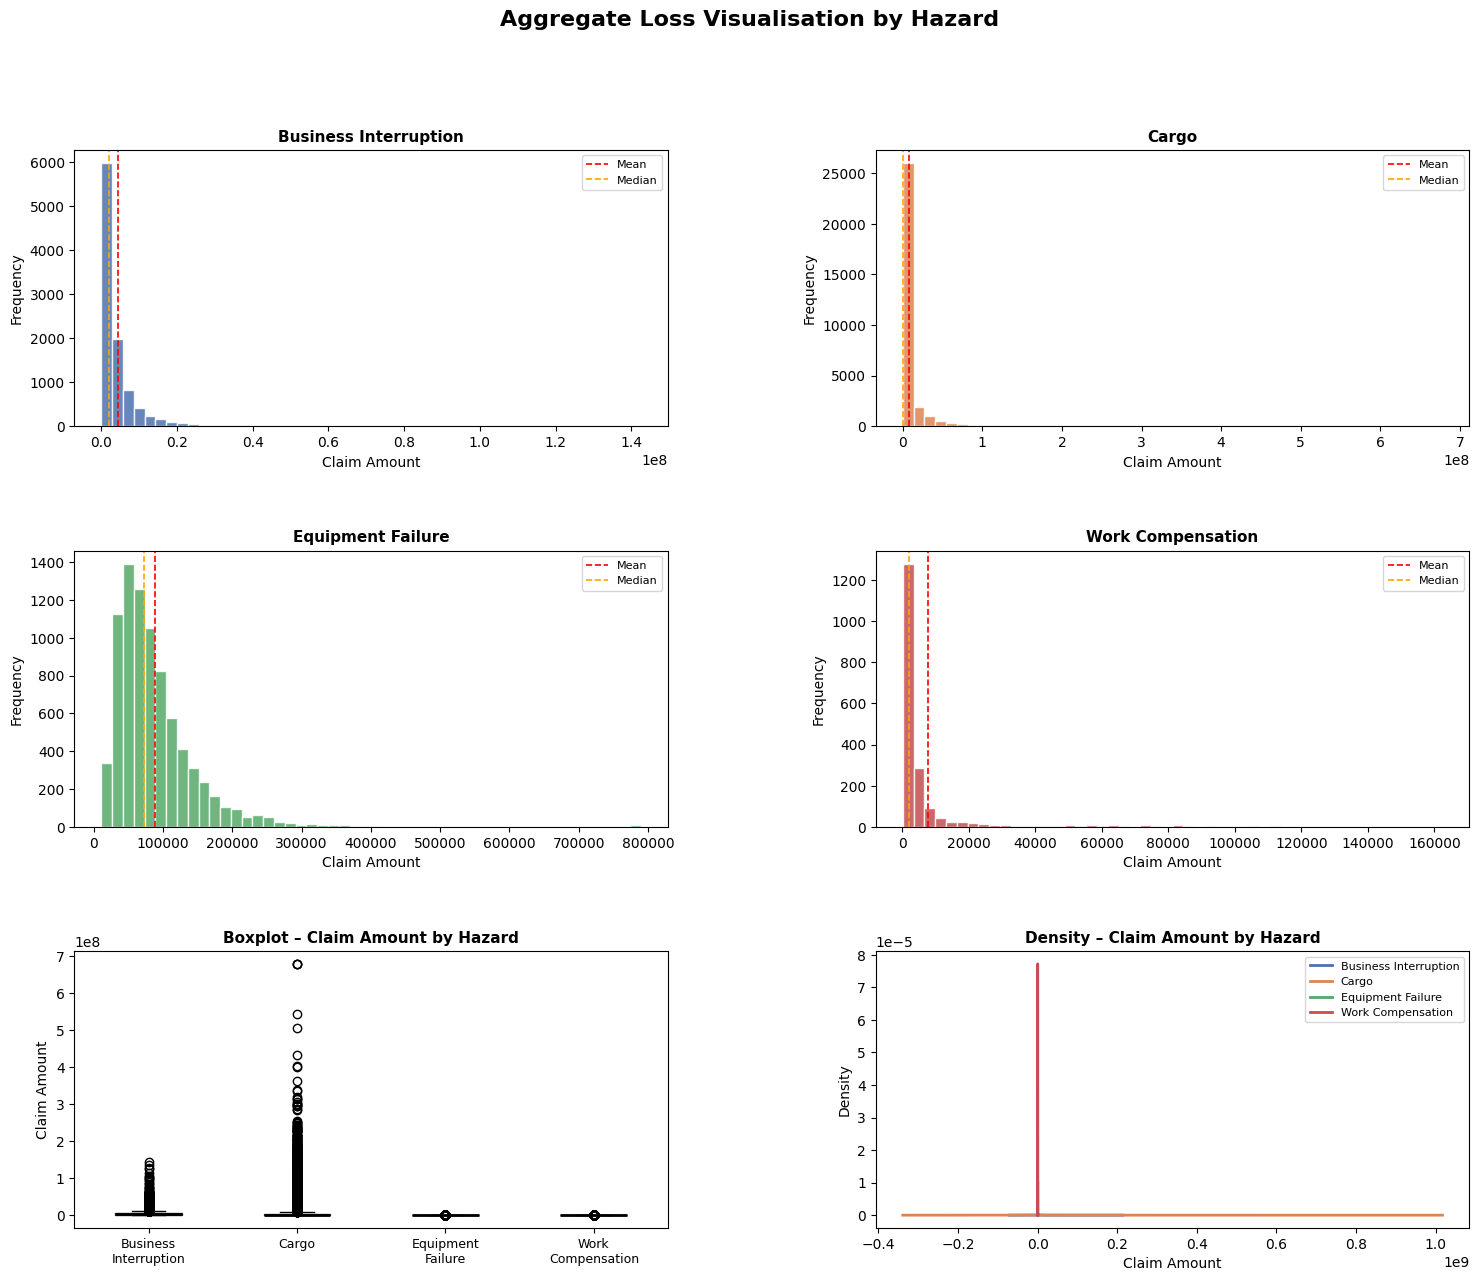

Plot saved: aggregate_loss_by_hazard.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── 1. Load data ──────────────────────────────────────────────
bi   = pd.read_excel("business_interruption_imputed.xlsx", sheet_name="sev")
cg   = pd.read_excel("cargo_imputed.xlsx",                 sheet_name="cargo_severity")
ef   = pd.read_excel("equipment_failure_imputed_data.xlsx",sheet_name="sev_final")
wc   = pd.read_excel("fix_cleaned_workcomp.xlsx",          sheet_name="sev")

hazards = {
    "Business Interruption": bi,
    "Cargo":                 cg,
    "Equipment Failure":     ef,
    "Work Compensation":     wc,
}

# ── 2. Summary stats ──────────────────────────────────────────
print("=" * 55)
for name, df in hazards.items():
    s = df["claim_amount"]
    print(f"\n{name}")
    print(f"  Count  : {len(s):,}")
    print(f"  Mean   : {s.mean():,.2f}")
    print(f"  Median : {s.median():,.2f}")
    print(f"  Std    : {s.std():,.2f}")
    print(f"  Min    : {s.min():,.2f}")
    print(f"  Max    : {s.max():,.2f}")
print("=" * 55)

# ── 3. Visualisasi ────────────────────────────────────────────
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Aggregate Loss Visualisation by Hazard", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# -- Plot 1: Histogram per hazard (2x2) -----------------------
for idx, (name, df) in enumerate(hazards.items()):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    ax.hist(df["claim_amount"], bins=50, color=colors[idx], edgecolor="white", alpha=0.85)
    ax.set_title(f"{name}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Claim Amount")
    ax.set_ylabel("Frequency")
    ax.axvline(df["claim_amount"].mean(),   color="red",    linestyle="--", linewidth=1.2, label="Mean")
    ax.axvline(df["claim_amount"].median(), color="orange", linestyle="--", linewidth=1.2, label="Median")
    ax.legend(fontsize=8)

# -- Plot 2: Boxplot side-by-side -----------------------------
ax_box = fig.add_subplot(gs[2, 0])
data_box  = [df["claim_amount"].dropna().values for df in hazards.values()]
labels    = [n.replace(" ", "\n") for n in hazards.keys()]
bp = ax_box.boxplot(data_box, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax_box.set_xticklabels(labels, fontsize=9)
ax_box.set_ylabel("Claim Amount")
ax_box.set_title("Boxplot – Claim Amount by Hazard", fontsize=11, fontweight="bold")

# -- Plot 3: Density overlay ----------------------------------
ax_kde = fig.add_subplot(gs[2, 1])
for (name, df), color in zip(hazards.items(), colors):
    df["claim_amount"].dropna().plot.kde(ax=ax_kde, label=name, color=color, linewidth=2)
ax_kde.set_xlabel("Claim Amount")
ax_kde.set_ylabel("Density")
ax_kde.set_title("Density – Claim Amount by Hazard", fontsize=11, fontweight="bold")
ax_kde.legend(fontsize=8)

plt.savefig("aggregate_loss_by_hazard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: aggregate_loss_by_hazard.png")

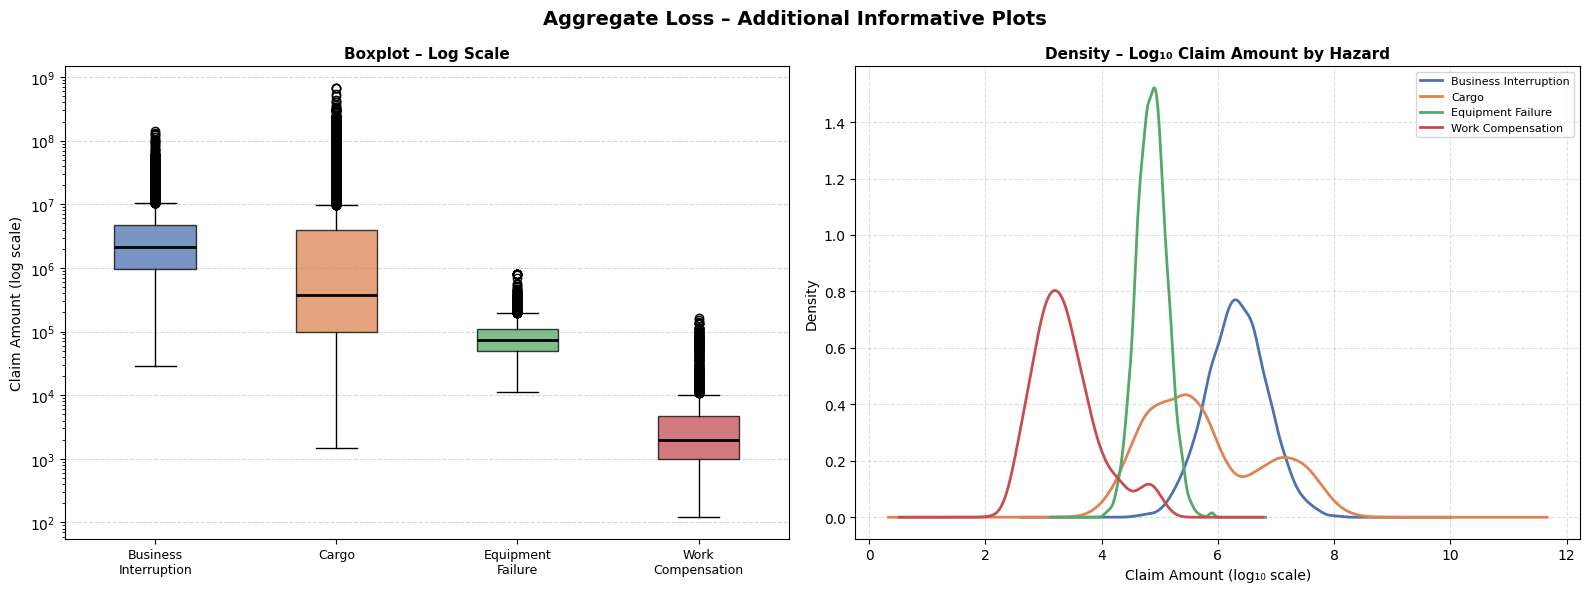

Saved: aggregate_loss_additional.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



hazards = {
    "Business Interruption": bi,
    "Cargo":                 cg,
    "Equipment Failure":     ef,
    "Work Compensation":     wc,
}
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Aggregate Loss – Additional Informative Plots", fontsize=14, fontweight="bold")

# -- Plot 1: Boxplot Log Scale --------------------------------
ax1 = axes[0]
data_box = [df["claim_amount"].dropna().values for df in hazards.values()]
labels   = [n.replace(" ", "\n") for n in hazards.keys()]
bp = ax1.boxplot(data_box, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax1.set_yscale("log")
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel("Claim Amount (log scale)")
ax1.set_title("Boxplot – Log Scale", fontsize=11, fontweight="bold")
ax1.yaxis.grid(True, linestyle="--", alpha=0.5)

# -- Plot 2: Density per hazard log X -------------------------
ax2 = axes[1]
for (name, df), color in zip(hazards.items(), colors):
    vals = df["claim_amount"].dropna()
    vals = vals[vals > 0]
    log_vals = np.log10(vals)
    log_vals.plot.kde(ax=ax2, label=name, color=color, linewidth=2)
ax2.set_xlabel("Claim Amount (log₁₀ scale)")
ax2.set_ylabel("Density")
ax2.set_title("Density – Log₁₀ Claim Amount by Hazard", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("aggregate_loss_additional.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: aggregate_loss_additional.png")